<a href="https://colab.research.google.com/github/UKD1211/DataScience_Slogbook_ISI_placement_prep/blob/main/pandas_5_merging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
courses = pd.read_csv('/content/courses.csv')
students = pd.read_csv('/content/students.csv')
nov = pd.read_csv('/content/reg-month1.csv')
dec = pd.read_csv('/content/reg-month2.csv')

matches = pd.read_csv('/content/matches.csv')
delivery = pd.read_csv('/content/deliveries (1).csv')

In [3]:
# pd.concat
# df.concat
# ignore_index
# df.append
# mullitindex -> fetch using iloc
# concat dataframes horizontally


In [4]:
students

,student_id,name,partner
0,1,Kailash Harjo,23
1,2,Esha Butala,1
2,3,Parveen Bhalla,3
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6
5,6,Lakshmi Contractor,10
6,7,Tarun Thaker,9
7,8,Radheshyam Dey,5
8,9,Nitika Chatterjee,4
9,10,Aayushman Sant,8


In [5]:
nov

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [6]:
regs = pd.concat([nov,dec], ignore_index = True)  #dfs will vertically merged #ignore_index removes the old indexes

In [7]:
regs

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [8]:
nov.append(dec)  #its no longer available here

AttributeError: 'DataFrame' object has no attribute 'append'

In [9]:
pd.concat([nov,dec],keys=['Nov','Dec'])
# Multi Index DataFrame

student_id  course_id
Nov 0           23          1
    1           15          5
    2           18          6
    3           23          4
    4           16          9
    5           18          1
    6            1          1
    7            7          8
    8           22          3
    9           15          1
    10          19          4
    11           1          6
    12           7         10
    13          11          7
    14          13          3
    15          24          4
    16          21          1
    17          16          5
    18          23          3
    19          17          7
    20          23          6
    21          25          1
    22          19          2
    23          25         10
    24           3          3
Dec 0            3          5
    1           16          7
    2           12         10
    3           12          1
    4           14          9
    5            7          7
    6            7          2
    7           16          3
    8           17         10
    9           11          8
    10          14          6
    11          12          5
    12          12          7
    13          18          8
    14           1         10
    15           1          9
    16           2          5
    17           7          6
    18          22          5
    19          22          6
    20          23          9
    21          23          5
    22          14          4
    23          14          1
    24          11         10
    25          42          9
    26          50          8
    27          38          1

In [10]:
multi = pd.concat([nov,dec],keys=['Nov','Dec'])
multi.loc['Nov']
multi.loc['Dec']

,student_id,course_id
0,3,5
1,16,7
2,12,10
3,12,1
4,14,9
5,7,7
6,7,2
7,16,3
8,17,10
9,11,8


In [11]:
multi.loc[('Nov',0)]  #nov er 1st banda

,Nov
,0
student_id,23
course_id,1


In [12]:
multi.loc[('Dec',5)]

,Dec
,5
student_id,7
course_id,7


In [13]:
# MultiIndexing is really great thing lol

In [14]:
# horizontally stacking
pd.concat([nov,dec], axis = 1)  #axis = 1 is for row wise

,student_id,course_id,student_id,course_id
0,23.0,1.0,3,5
1,15.0,5.0,16,7
2,18.0,6.0,12,10
3,23.0,4.0,12,1
4,16.0,9.0,14,9
5,18.0,1.0,7,7
6,1.0,1.0,7,2
7,7.0,8.0,16,3
8,22.0,3.0,17,10
9,15.0,1.0,11,8


In [15]:
#join is like we have to add 2 tables or df on basis of their one common column

In [16]:
# inner join
students.merge(regs,how='inner',on='student_id')

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5
5,3,Parveen Bhalla,3,3
6,3,Parveen Bhalla,3,5
7,7,Tarun Thaker,9,8
8,7,Tarun Thaker,9,10
9,7,Tarun Thaker,9,7


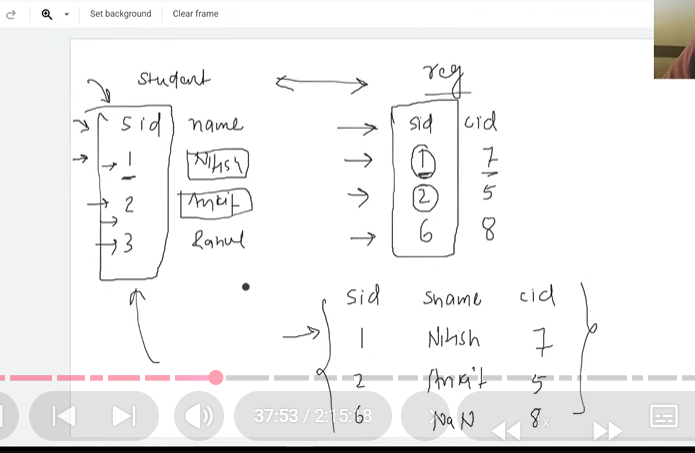

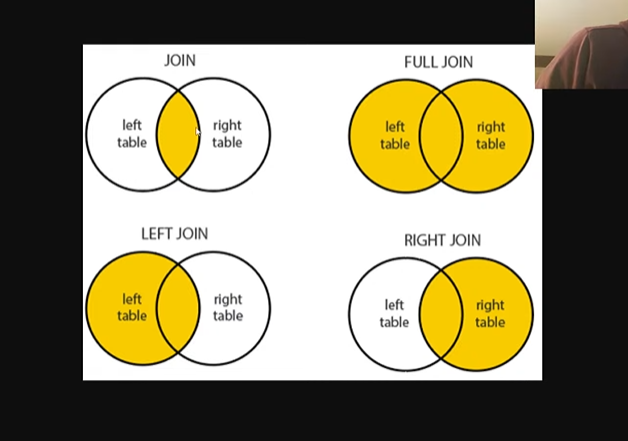

In [17]:
# left join
# the full left table will appear
courses.merge(regs, how='left',on='course_id')

,course_id,course_name,price,student_id
0,1,python,2499,23.0
1,1,python,2499,18.0
2,1,python,2499,1.0
3,1,python,2499,15.0
4,1,python,2499,21.0
5,1,python,2499,25.0
6,1,python,2499,12.0
7,1,python,2499,14.0
8,1,python,2499,38.0
9,2,sql,3499,19.0


In [18]:
# right join
temp_df = pd.DataFrame({
    'student_id':[26,27,28],
    'name':['Nitish','Ankit','Rahul'],
    'partner':[28,26,17]
})

students = pd.concat([students,temp_df],ignore_index=True)

In [19]:
students.merge(regs,how='right',on='student_id')

,student_id,name,partner,course_id
0,23,Chhavi Lachman,18.0,1
1,15,Preet Sha,16.0,5
2,18,Fardeen Mahabir,13.0,6
3,23,Chhavi Lachman,18.0,4
4,16,Elias Dodiya,25.0,9
5,18,Fardeen Mahabir,13.0,1
6,1,Kailash Harjo,23.0,1
7,7,Tarun Thaker,9.0,8
8,22,Yash Sethi,21.0,3
9,15,Preet Sha,16.0,1


In [20]:
# outer join
students.merge(regs,how='outer',on='student_id').tail(10)

,student_id,name,partner,course_id
53,23,Chhavi Lachman,18.0,5.0
54,24,Radhika Suri,17.0,4.0
55,25,Shashank D’Alia,2.0,1.0
56,25,Shashank D’Alia,2.0,10.0
57,26,Nitish,28.0,NaN
58,27,Ankit,26.0,NaN
59,28,Rahul,17.0,NaN
60,38,NaN,NaN,1.0
61,42,NaN,NaN,9.0
62,50,NaN,NaN,8.0


In [21]:
# 99% times we only use the inner joins

In [29]:
#1 find total revenue generated by company
courses.merge(regs,how="inner",on="course_id").groupby('course_name')['price'].sum()

,price
course_name,
data analysis,24995
machine learning,39996
ms sxcel,7995
pandas,4396
plotly,3495
power bi,11394
pyspark,14994
python,22491
sql,6998


In [32]:
courses.merge(regs,how="inner",on="course_id")['price'].sum()

np.int64(154247)

In [38]:
#2 find month by month revenue
nov.merge(courses,how="inner",on="course_id")['price'].sum()

np.int64(89175)

In [39]:
dec.merge(courses,how="inner",on="course_id")['price'].sum()

np.int64(65072)

In [44]:
temp_df = pd.concat([nov,dec],keys=['Nov','Dec']).reset_index() #multi_indexing and reset_index

In [45]:
temp_df.merge(courses,how="inner",on="course_id")

,level_0,level_1,student_id,course_id,course_name,price
0,Nov,0,23,1,python,2499
1,Nov,1,15,5,tableau,2499
2,Nov,2,18,6,power bi,1899
3,Nov,3,23,4,machine learning,9999
4,Nov,4,16,9,plotly,699
5,Nov,5,18,1,python,2499
6,Nov,6,1,1,python,2499
7,Nov,7,7,8,pandas,1099
8,Nov,8,22,3,data analysis,4999
9,Nov,9,15,1,python,2499


In [48]:
temp_df.merge(courses,how="inner",on="course_id").groupby('level_0')['price'].sum()

,price
level_0,
Dec,65072
Nov,89175


In [51]:
#3 print the registration table
# col name, course, price
regs.merge(students,how="inner",on="student_id").merge(courses,how="inner",on="course_id")[['name','course_name','price']]

,name,course_name,price
0,Chhavi Lachman,python,2499
1,Preet Sha,tableau,2499
2,Fardeen Mahabir,power bi,1899
3,Chhavi Lachman,machine learning,9999
4,Elias Dodiya,plotly,699
5,Fardeen Mahabir,python,2499
6,Kailash Harjo,python,2499
7,Tarun Thaker,pandas,1099
8,Yash Sethi,data analysis,4999
9,Preet Sha,python,2499


In [53]:
#4 plot a bar chart for revenue/course
courses

,course_id,course_name,price
0,1,python,2499
1,2,sql,3499
2,3,data analysis,4999
3,4,machine learning,9999
4,5,tableau,2499
5,6,power bi,1899
6,7,ms sxcel,1599
7,8,pandas,1099
8,9,plotly,699
9,10,pyspark,2499


<Axes: xlabel='course_name'>

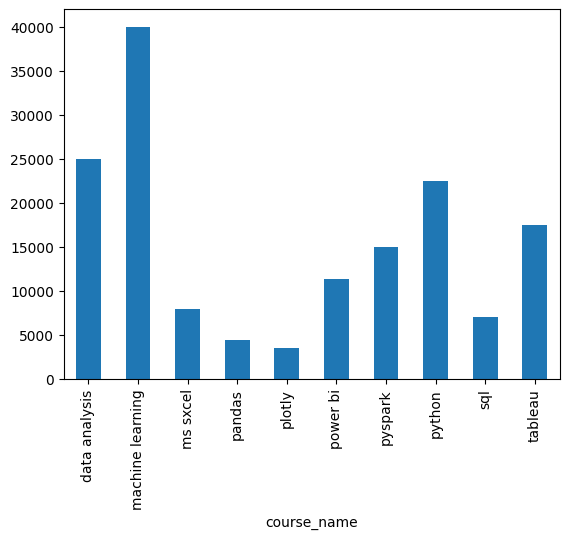

In [60]:
regs.merge(courses,how="inner",on="course_id").groupby('course_name')['price'].sum().plot(kind='bar')

In [61]:
#5 Find the students who enrolled in both the months
students

,student_id,name,partner
0,1,Kailash Harjo,23
1,2,Esha Butala,1
2,3,Parveen Bhalla,3
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6
5,6,Lakshmi Contractor,10
6,7,Tarun Thaker,9
7,8,Radheshyam Dey,5
8,9,Nitika Chatterjee,4
9,10,Aayushman Sant,8


In [68]:
pd.concat([nov,dec],keys=['Nov','Dec']).reset_index().merge(students,how="inner",on="student_id")

,level_0,level_1,student_id,course_id,name,partner
0,Nov,0,23,1,Chhavi Lachman,18
1,Nov,1,15,5,Preet Sha,16
2,Nov,2,18,6,Fardeen Mahabir,13
3,Nov,3,23,4,Chhavi Lachman,18
4,Nov,4,16,9,Elias Dodiya,25
5,Nov,5,18,1,Fardeen Mahabir,13
6,Nov,6,1,1,Kailash Harjo,23
7,Nov,7,7,8,Tarun Thaker,9
8,Nov,8,22,3,Yash Sethi,21
9,Nov,9,15,1,Preet Sha,16


In [71]:
common_studentid = np.intersect1d(nov['student_id'],dec['student_id'])  #enrolled in both months

In [72]:
common_studentid

array([ 1,  3,  7, 11, 16, 17, 18, 22, 23])

In [74]:
students[students['student_id'].isin(common_studentid)]  #got the loyal customers

,student_id,name,partner
0,1,Kailash Harjo,23
2,3,Parveen Bhalla,3
6,7,Tarun Thaker,9
10,11,David Mukhopadhyay,20
15,16,Elias Dodiya,25
16,17,Yasmin Palan,7
17,18,Fardeen Mahabir,13
21,22,Yash Sethi,21
22,23,Chhavi Lachman,18


In [85]:
#6. Find course that got no enrollment
courses.merge(regs,how="left",on="course_id")[courses.merge(regs,how="left",on="course_id")['student_id'].isnull()]['course_name']

,course_name
53,Numpy
54,C++


In [90]:
# courses['course_id']
# regs['course_id']

course_id_list = np.setdiff1d(courses['course_id'],regs['course_id'])

In [91]:
courses[courses['course_id'].isin(course_id_list)]

,course_id,course_name,price
10,11,Numpy,699
11,12,C++,1299


In [92]:
#7. Find the students who did not apply into any courses

In [93]:
students

,student_id,name,partner
0,1,Kailash Harjo,23
1,2,Esha Butala,1
2,3,Parveen Bhalla,3
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6
5,6,Lakshmi Contractor,10
6,7,Tarun Thaker,9
7,8,Radheshyam Dey,5
8,9,Nitika Chatterjee,4
9,10,Aayushman Sant,8


In [98]:
student_list = np.setdiff1d(students['student_id'],regs['student_id'])
students[students['student_id'].isin(student_list)]

,student_id,name,partner
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6
5,6,Lakshmi Contractor,10
7,8,Radheshyam Dey,5
8,9,Nitika Chatterjee,4
9,10,Aayushman Sant,8
19,20,Hanuman Hegde,11
25,26,Nitish,28
26,27,Ankit,26
27,28,Rahul,17


In [99]:
#8 print student name-> partner name for all enrolled students #VVIP

In [102]:
students

,student_id,name,partner
0,1,Kailash Harjo,23
1,2,Esha Butala,1
2,3,Parveen Bhalla,3
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6
5,6,Lakshmi Contractor,10
6,7,Tarun Thaker,9
7,8,Radheshyam Dey,5
8,9,Nitika Chatterjee,4
9,10,Aayushman Sant,8


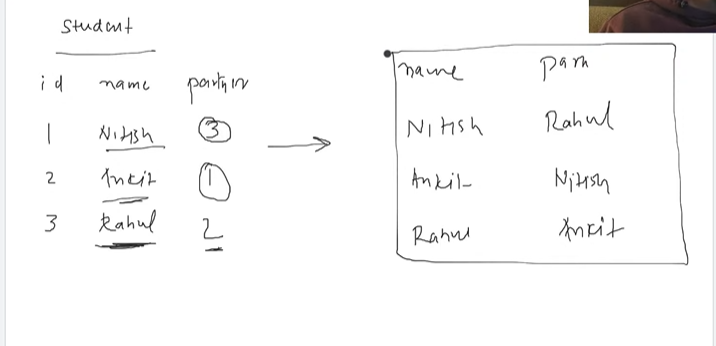

In [105]:
#self join #same tables joining #kotheen jinis

students.merge(students,how="inner",left_on="partner",right_on="student_id")[['name_x','name_y']]

,name_x,name_y
0,Kailash Harjo,Chhavi Lachman
1,Esha Butala,Kailash Harjo
2,Parveen Bhalla,Parveen Bhalla
3,Marlo Dugal,Pranab Natarajan
4,Kusum Bahri,Lakshmi Contractor
5,Lakshmi Contractor,Aayushman Sant
6,Tarun Thaker,Nitika Chatterjee
7,Radheshyam Dey,Kusum Bahri
8,Nitika Chatterjee,Marlo Dugal
9,Aayushman Sant,Radheshyam Dey


In [106]:
#9 Find the 3 students who did the most number of enrollments

In [116]:
regs.merge(students,how="inner",on="student_id").groupby("name")['course_id'].count().sort_values(ascending=False).head(3)

,course_id
name,
Chhavi Lachman,6
Tarun Thaker,5
Radha Dutt,4
